In [16]:
# Imports
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Initial EDA

## 1. Load and shape check


In [17]:
df = pd.read_csv("../data/creditcard.csv", sep=",")
print(df.shape)

(284807, 31)


In [18]:
print(f"Dataset contains {df.shape[0]} rows, {df.shape[1]} columns.")
print(f"Columns with nulls: {(df.notna().sum() < df.shape[0]).sum()}")

Dataset contains 284807 rows, 31 columns.
Columns with nulls: 0


In [19]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2. Class imbalance

In [20]:
# Quick check of class volumes
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [21]:
# Calculate percentage of fraud cases in dataset
print(f"Positive class: {df['Class'].sum() / df['Class'].count():.2%}")

Positive class: 0.17%


## 3. Feature distributions

array([<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
      dtype=object)

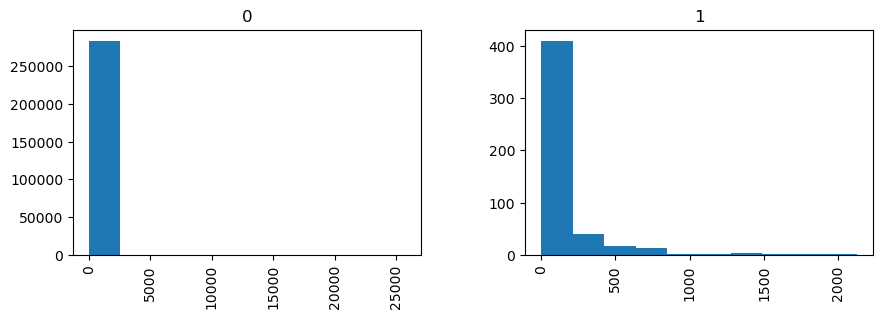

In [22]:
df.hist(column="Amount", by="Class", figsize=(10,3))

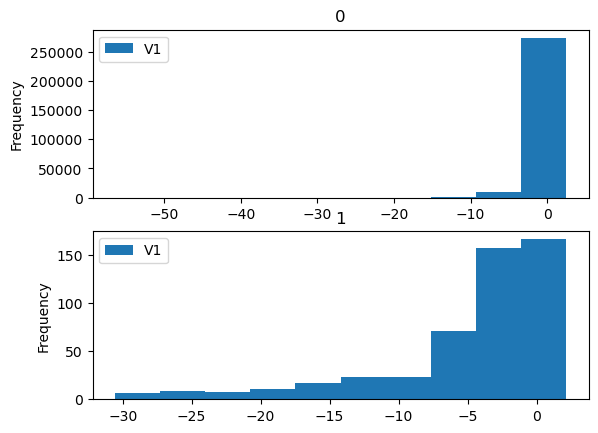

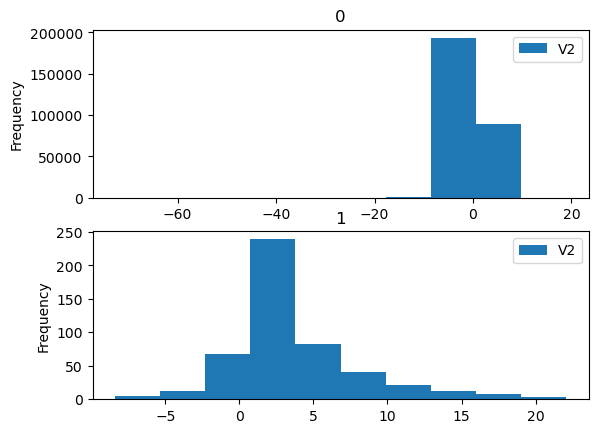

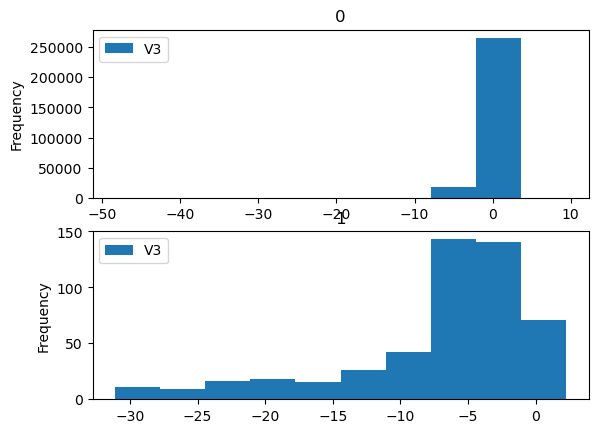

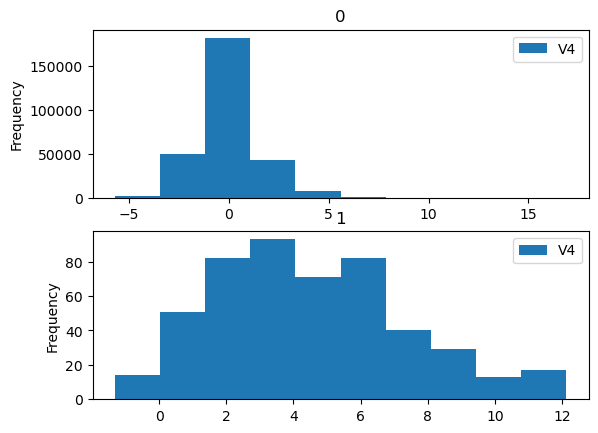

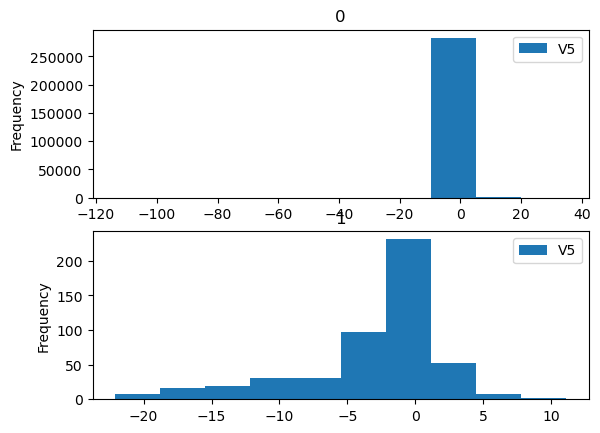

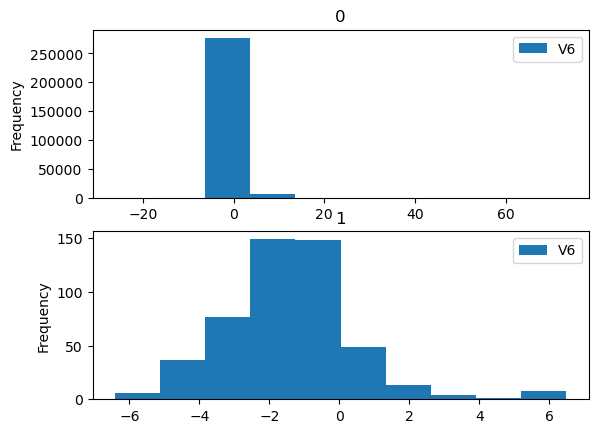

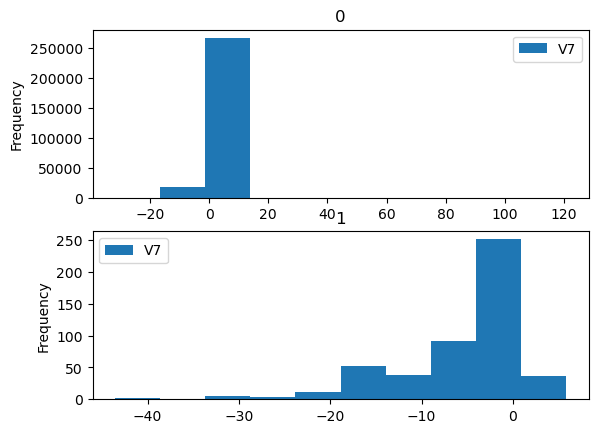

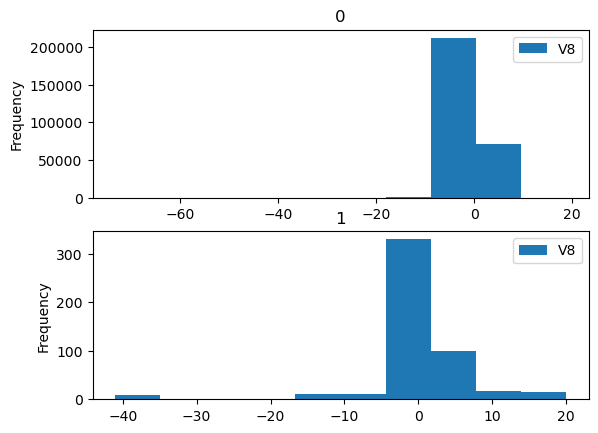

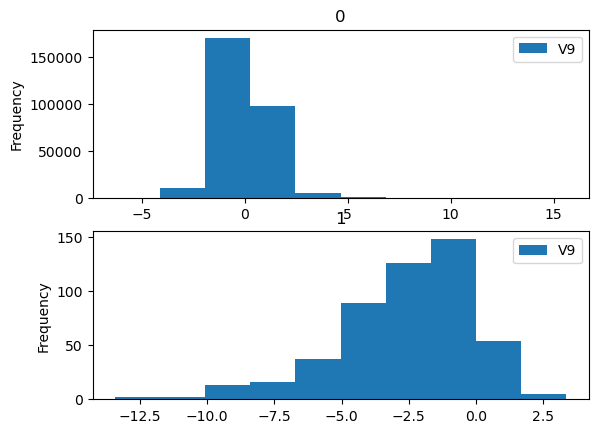

In [23]:
cols_to_plot = [col for col in df.columns if col[:1]=='V' and len(col)==2]
for col in cols_to_plot:
    df.plot(kind="hist",column=col, by="Class")

## 4. Preprocessing

In [24]:
# Drop Time column as not relevant
df = df.drop(columns=['Time'])

In [25]:
# Rescale Amount column
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

In [26]:
# Quick check of transformation: mean should be ~0, std ~1
df[['Amount', 'Amount_scaled']].describe()

,Amount,Amount_scaled
count,284807.000000,2.848070e+05
mean,88.349619,2.913952e-17
std,250.120109,1.000002e+00
min,0.000000,-3.532294e-01
25%,5.600000,-3.308401e-01
50%,22.000000,-2.652715e-01
75%,77.165000,-4.471707e-02
max,25691.160000,1.023622e+02


## 5. Export dataset & scaler

In [27]:
# Save processed dataframe to csv
df.to_csv("../data/creditcard_processed.csv")

# Save StandardScaler object for later use in pipeline
import pickle
pickle.dump(scaler, open('../models/amount_scaler.pkl', 'wb'))